In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

df=pd.read_csv('data/zomato_clean.csv')
print("Shape:", df.shape)
df.head()

Shape: (51696, 19)


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,cost_for_two,reviews_list,menu_item,listed_type,listed_city,cuisine_count,primary_cuisine
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,1,1,4.1,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari,3.0,North Indian
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,1,0,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari,3.0,Chinese
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,1,0,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari,3.0,Cafe
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,0,0,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari,2.0,South Indian
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,0,0,3.8,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari,2.0,North Indian


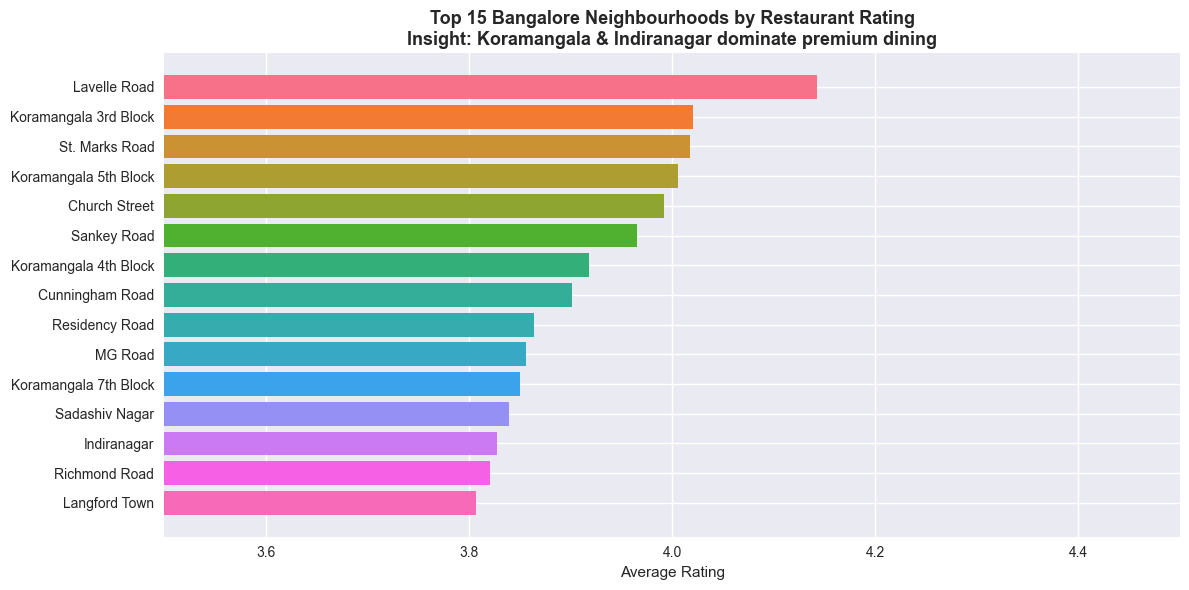

Chart 1 saved


In [39]:
top_locations = (df[df['rate'].notna()]
                 .groupby('location')
                 .agg(avg_rating=('rate', 'mean'),
                      total_restaurants=('name', 'count'))
                 .query('total_restaurants >= 20')
                 .sort_values('avg_rating', ascending=False)
                 .head(15)
                 .reset_index())

plt.figure(figsize=(12, 6))
bars = plt.barh(top_locations['location'], 
                top_locations['avg_rating'],
                color=sns.color_palette("husl", 15))
plt.xlabel('Average Rating')
plt.title('Top 15 Bangalore Neighbourhoods by Restaurant Rating\n'
          'Insight: Koramangala & Indiranagar dominate premium dining', 
          fontsize=13, fontweight='bold')
plt.xlim(3.5, 4.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print("Chart 1 saved")

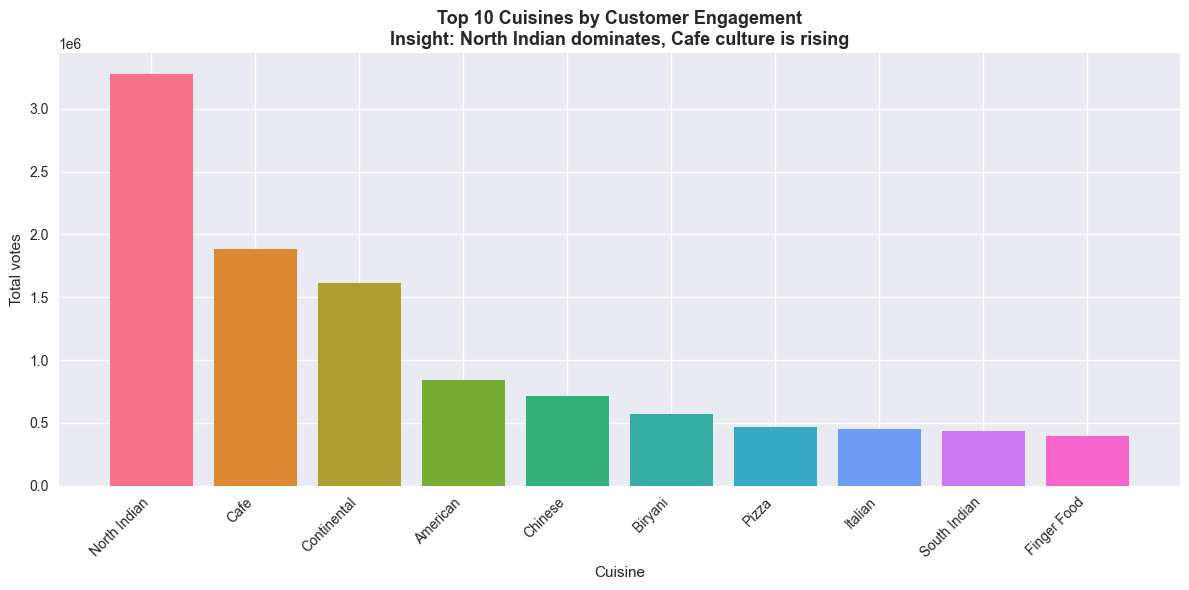

Chart 2 saved


In [40]:
top_cuisines=(df[df['primary_cuisine']!='Unknown']
              .groupby('primary_cuisine')
              .agg(total_votes=('votes','sum'),
                   restaurant_count=('name','count'))
                .query('restaurant_count >=15')
                .sort_values('total_votes', ascending=False)
                .head(10)
                .reset_index())

plt.figure(figsize=(12,6))
plt.bar(top_cuisines['primary_cuisine'],
        top_cuisines['total_votes'],
        color=sns.color_palette("husl",10))
plt.xlabel('Cuisine')
plt.ylabel('Total votes')
plt.title('Top 10 Cuisines by Customer Engagement\n'
          'Insight: North Indian dominates, Cafe culture is rising',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Chart 2 saved")


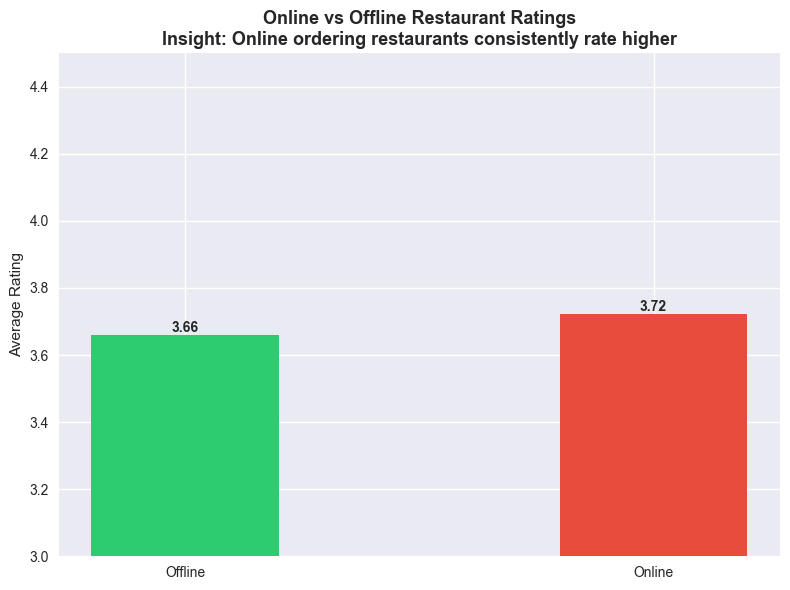

Chart 3 saved


In [41]:
online_stats = (df[df['rate'].notna()]
                .groupby('online_order')
                .agg(avg_rating=('rate', 'mean'),
                     restaurant_count=('name', 'count'))
                .reset_index())

online_stats['order_mode'] = online_stats['online_order'].map({1: 'Online', 0: 'Offline'})

plt.figure(figsize=(8, 6))
bars = plt.bar(online_stats['order_mode'],
               online_stats['avg_rating'],
               color=['#2ecc71', '#e74c3c'],
               width=0.4)

for bar, val in zip(bars, online_stats['avg_rating']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.2f}',
             ha='center', fontweight='bold')

plt.ylabel('Average Rating')
plt.title('Online vs Offline Restaurant Ratings\n'
          'Insight: Online ordering restaurants consistently rate higher',
          fontsize=13, fontweight='bold')
plt.ylim(3.0, 4.5)
plt.tight_layout()
plt.show()
print("Chart 3 saved")

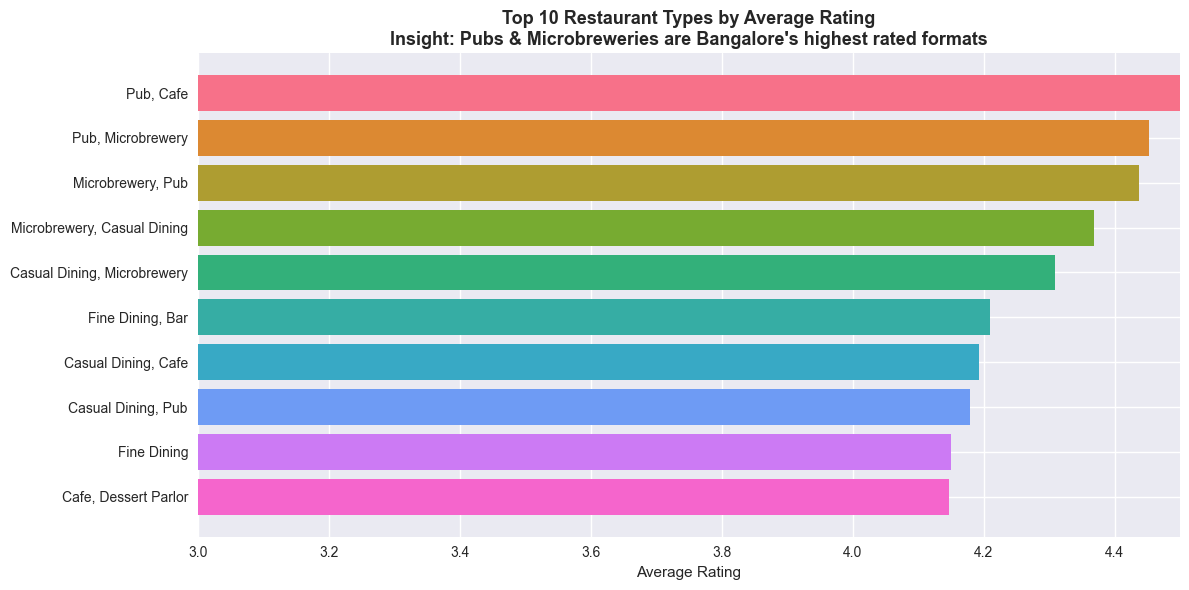

Chart 4 saved


In [42]:
rest_type_stats = (df[df['rate'].notna()]
                   .query("rest_type != 'Unknown'")
                   .groupby('rest_type')
                   .agg(avg_rating=('rate', 'mean'),
                        count=('name', 'count'))
                   .query('count >= 30')
                   .sort_values('avg_rating', ascending=False)
                   .head(10)
                   .reset_index())

plt.figure(figsize=(12, 6))
bars = plt.barh(rest_type_stats['rest_type'],
                rest_type_stats['avg_rating'],
                color=sns.color_palette("husl", 10))
plt.xlabel('Average Rating')
plt.title('Top 10 Restaurant Types by Average Rating\n'
          'Insight: Pubs & Microbreweries are Bangalore\'s highest rated formats',
          fontsize=13, fontweight='bold')
plt.xlim(3.0, 4.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print("Chart 4 saved")

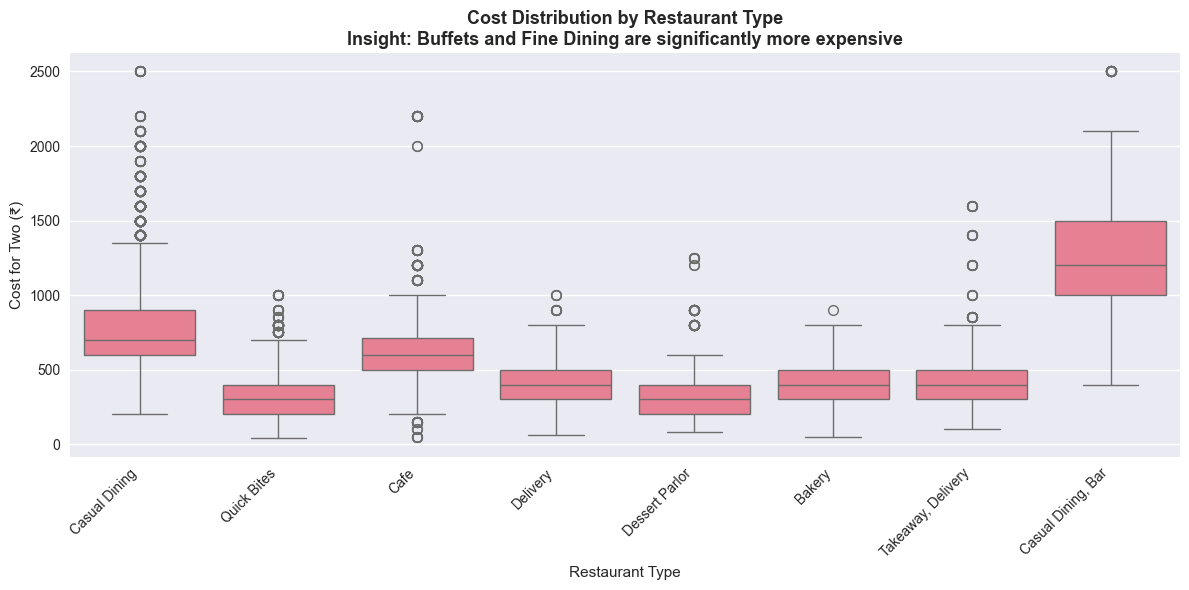

Chart 5 saved


In [43]:
plt.figure(figsize=(12, 6))
top_types = df['rest_type'].value_counts().head(8).index
df_filtered = df[df['rest_type'].isin(top_types)]
sns.boxplot(data=df_filtered, x='rest_type', y='cost_for_two')
plt.xlabel('Restaurant Type')
plt.ylabel('Cost for Two (₹)')
plt.title('Cost Distribution by Restaurant Type\n'
          'Insight: Buffets and Fine Dining are significantly more expensive',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Chart 5 saved")

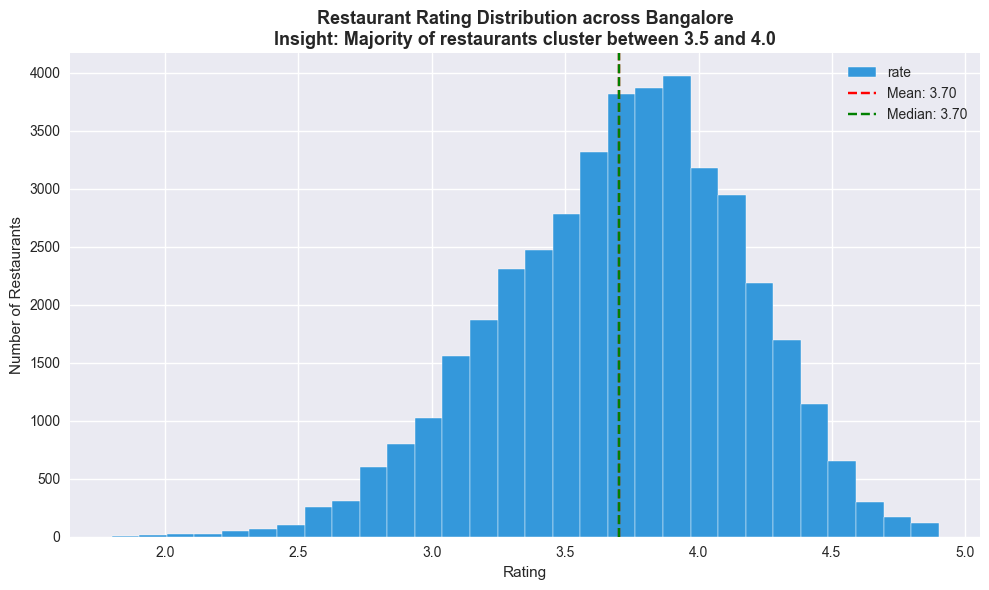

Chart 6 saved


In [44]:
plt.figure(figsize=(10, 6))
df['rate'].dropna().plot(kind='hist', bins=30, color='#3498db', 
                          edgecolor='white')
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')
plt.title('Restaurant Rating Distribution across Bangalore\n'
          'Insight: Majority of restaurants cluster between 3.5 and 4.0',
          fontsize=13, fontweight='bold')
plt.axvline(df['rate'].mean(), color='red', linestyle='--', 
            label=f'Mean: {df["rate"].mean():.2f}')
plt.axvline(df['rate'].median(), color='green', linestyle='--',
            label=f'Median: {df["rate"].median():.2f}')
plt.legend()
plt.tight_layout()
plt.show()
print("Chart 6 saved")

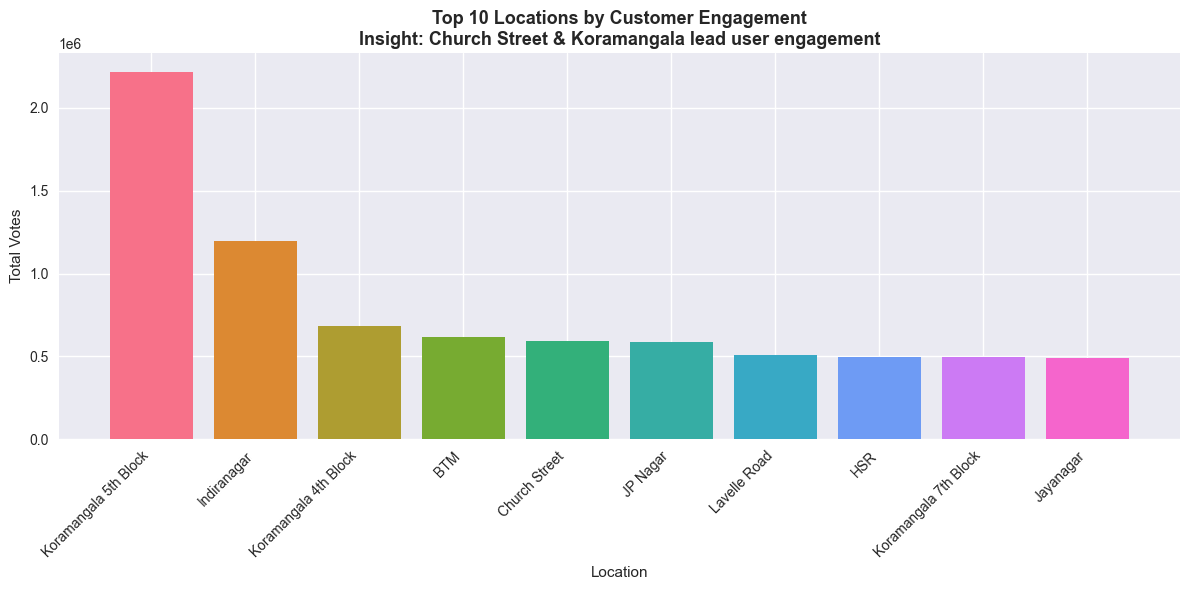

Chart 7 saved


In [45]:
top_engaged = (df.groupby('location')
               .agg(total_votes=('votes', 'sum'),
                    count=('name', 'count'))
               .query('count >= 20')
               .sort_values('total_votes', ascending=False)
               .head(10)
               .reset_index())

plt.figure(figsize=(12, 6))
plt.bar(top_engaged['location'],
        top_engaged['total_votes'],
        color=sns.color_palette("husl", 10))
plt.xlabel('Location')
plt.ylabel('Total Votes')
plt.title('Top 10 Locations by Customer Engagement\n'
          'Insight: Church Street & Koramangala lead user engagement',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Chart 7 saved")

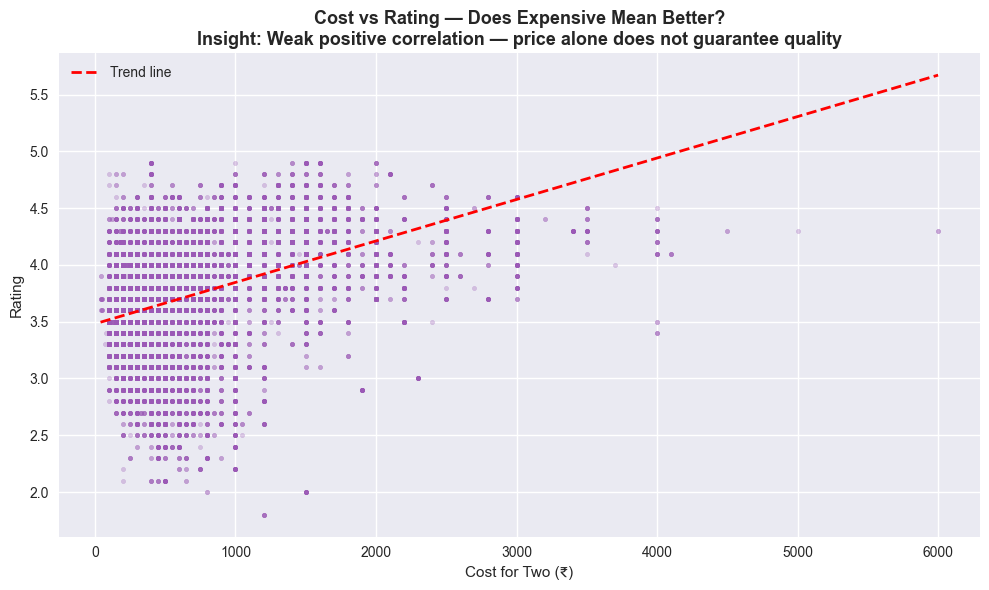

Chart 8 saved


In [46]:
plt.figure(figsize=(10, 6))
plt.scatter(df['cost_for_two'], df['rate'],
            alpha=0.3, color='#9b59b6', s=10)
plt.xlabel('Cost for Two (₹)')
plt.ylabel('Rating')
plt.title('Cost vs Rating — Does Expensive Mean Better?\n'
          'Insight: Weak positive correlation — price alone does not guarantee quality',
          fontsize=13, fontweight='bold')

import numpy as np
df_clean = df[df['rate'].notna() & df['cost_for_two'].notna()]
z = np.polyfit(df_clean['cost_for_two'], df_clean['rate'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean['cost_for_two'].min(), 
                      df_clean['cost_for_two'].max(), 100)
plt.plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend line')
plt.legend()
plt.tight_layout()
plt.show()
print("Chart 8 saved")

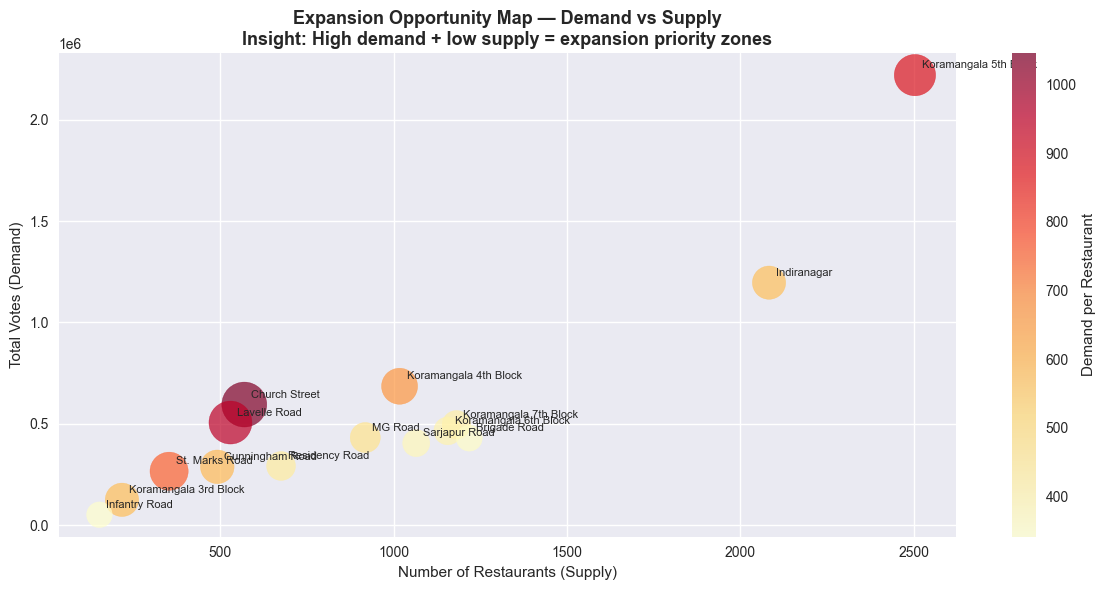

Chart 9 saved


In [47]:
location_stats = (df.groupby('location')
                  .agg(restaurant_count=('name', 'count'),
                       total_votes=('votes', 'sum'))
                  .reset_index())

location_stats['demand_per_restaurant'] = (location_stats['total_votes'] / 
                                            location_stats['restaurant_count'])

top_opportunity = (location_stats
                   .query('restaurant_count >= 10')
                   .sort_values('demand_per_restaurant', ascending=False)
                   .head(15))

plt.figure(figsize=(12, 6))
scatter = plt.scatter(top_opportunity['restaurant_count'],
                      top_opportunity['total_votes'],
                      s=top_opportunity['demand_per_restaurant'],
                      c=top_opportunity['demand_per_restaurant'],
                      cmap='YlOrRd', alpha=0.7)
plt.colorbar(scatter, label='Demand per Restaurant')

for _, row in top_opportunity.iterrows():
    plt.annotate(row['location'],
                 (row['restaurant_count'], row['total_votes']),
                 textcoords="offset points",
                 xytext=(5, 5), fontsize=8)

plt.xlabel('Number of Restaurants (Supply)')
plt.ylabel('Total Votes (Demand)')
plt.title('Expansion Opportunity Map — Demand vs Supply\n'
          'Insight: High demand + low supply = expansion priority zones',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Chart 9 saved")

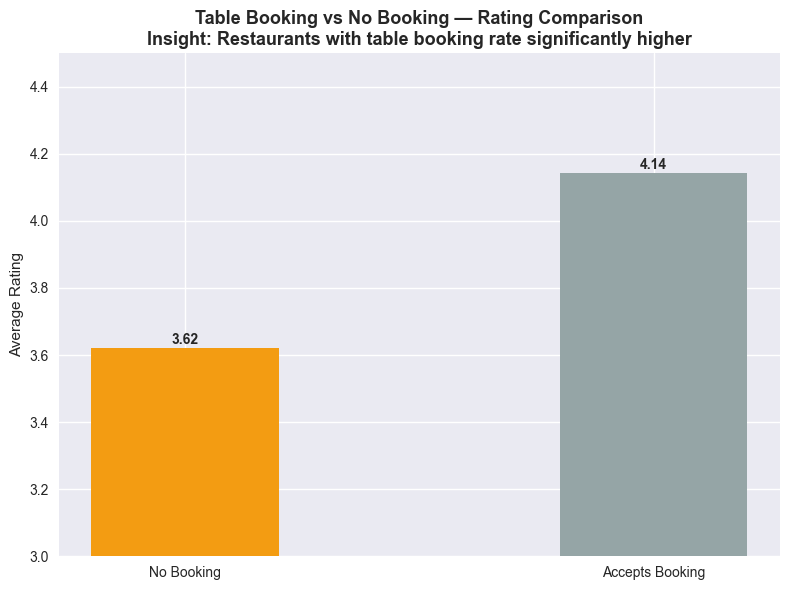

Chart 10 saved


In [48]:
book_stats = (df[df['rate'].notna()]
              .groupby('book_table')
              .agg(avg_rating=('rate', 'mean'),
                   count=('name', 'count'))
              .reset_index())

book_stats['booking'] = book_stats['book_table'].map({1: 'Accepts Booking', 
                                                       0: 'No Booking'})

plt.figure(figsize=(8, 6))
bars = plt.bar(book_stats['booking'],
               book_stats['avg_rating'],
               color=['#f39c12', '#95a5a6'],
               width=0.4)

for bar, val in zip(bars, book_stats['avg_rating']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.2f}',
             ha='center', fontweight='bold')

plt.ylabel('Average Rating')
plt.title('Table Booking vs No Booking — Rating Comparison\n'
          'Insight: Restaurants with table booking rate significantly higher',
          fontsize=13, fontweight='bold')
plt.ylim(3.0, 4.5)
plt.tight_layout()
plt.show()
print("Chart 10 saved")